CONTENTS:
- [Description](#description)
- [Imports](#imports)
- [Config](#config)
- [Generate data](#generate-data)
- [Fit the model](#fit-the-model)
- [Predict](#predict)
- [Analyze the results](#analyze-the-results)
    - [`Prophet.plot()`](#`prophet.plot()`)
    - [`Prophet.plot_components()`](#`prophet.plot_components()`)
    - [Prophet.plot_plotly()](#prophet.plot_plotly())
- [Performance metrics](#performance-metrics)
- [Cross Validation](#cross-validation)

<a name='description'></a>
# Description

The notebook shows how to perform time series prediction using the Prophet model developed by Facebook.

References:
- White paper: `https://peerj.com/preprints/3190.pdf`
- Official docs: `https://facebook.github.io/prophet/docs/quick_start.html`

<a name='imports'></a>
# Imports

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import logging

import helpers.hdbg as hdbg
import helpers.hpandas as hpandas
import helpers.hprint as hprint
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import prophet.diagnostics as diagnostics
import prophet.plot as plo
import prophet.utilities as prhu
import scipy.stats as stats
import sklearn.metrics as metrics

from tutorial_prophet.src.prophet_model import ProphetForecastModel

In [3]:
hdbg.init_logger(verbosity=logging.INFO)

_LOG = logging.getLogger(__name__)

hprint.config_notebook()

INFO  > cmd='/home/alvinoangelo/src/venv/client_venv.helpers/lib/python3.12/site-packages/ipykernel_launcher.py -f /home/alvinoangelo/.local/share/jupyter/runtime/kernel-daf90cdb-f753-436d-83e2-b89535bdc2a4.json'


<a name='config'></a>
# Config

In [4]:
config = {
    # Train/test split.
    "train_start_date": "2020-01-01",
    "train_end_date": "2023-12-31",
    "test_start_date": "2024-01-01",
    "test_end_date": "2024-12-31",
    "data": {
        # Linear trend params.
        "slope": 0.005,
        "intercept": 15,
        # Fourier term params for seasonality component.
        "weekly_amp_sin": 5.0,
        "weekly_amp_cos": 2.5,
        # List of holidays and their impact.
        "holidays_dates": [
            "2020-12-25",
            "2021-12-25",
            "2022-12-25",
            "2023-12-25",
            "2024-12-25",
        ],
        "holidays_impact": 2.5,
        # Autoregression params.
        "ar_order": 1,
        "phi": 0.7,
        # Noise std.
        "seed": 42,
        "noise_sigma": 2.0,
    },
    "model": {
        # Defines trend shape.
        "growth": "linear",
        "yearly_seasonality": False,
        # Integer defines Fourier order.
        "weekly_seasonality": 1,
        "daily_seasonality": False,
        "n_changepoints": 0,
        # Prophet internally scales the target variable.
        "scaling": "minmax",
        # Confidence iterval width.
        "interval_width": 0.95,
        # Number of MCMC samples; If `mcmc_samples = 0`, the model produces just a point estimate  of each
        # parameter instead of the full distribution.
        "mcmc_samples": 300,
        # Set lower prior scale to narrow the confidence interval.
        "holidays_prior_scale": 0.1,
    },
}
print(config)

{'train_start_date': '2020-01-01', 'train_end_date': '2023-12-31', 'test_start_date': '2024-01-01', 'test_end_date': '2024-12-31', 'data': {'slope': 0.005, 'intercept': 15, 'weekly_amp_sin': 5.0, 'weekly_amp_cos': 2.5, 'holidays_dates': ['2020-12-25', '2021-12-25', '2022-12-25', '2023-12-25', '2024-12-25'], 'holidays_impact': 2.5, 'ar_order': 1, 'phi': 0.7, 'seed': 42, 'noise_sigma': 2.0}, 'model': {'growth': 'linear', 'yearly_seasonality': False, 'weekly_seasonality': 1, 'daily_seasonality': False, 'n_changepoints': 0, 'scaling': 'minmax', 'interval_width': 0.95, 'mcmc_samples': 300, 'holidays_prior_scale': 0.1}}


<a name='generate-data'></a>
# Generate data

In [5]:
# Generate date range.
dates = pd.date_range(
    start=config["train_start_date"], end=config["test_end_date"], freq="D"
)
time = np.arange(len(dates))
# Define linear trend.
y_trend = config["data"]["slope"] * time + config["data"]["intercept"]
# Define the seasonality factor.
p_weekly = 7
y_weekly_seasonality = config["data"]["weekly_amp_sin"] * np.sin(
    2 * np.pi * time / p_weekly
) + config["data"]["weekly_amp_cos"] * np.cos(2 * np.pi * time / p_weekly)
# Define holidays impact.
holiday_effect = np.zeros(len(dates))
holiday_effect[
    np.isin(dates.date, pd.to_datetime(config["data"]["holidays_dates"]).date)
] = config["data"]["holidays_impact"]
# Define white noise.
np.random.seed(config["data"]["seed"])
noise = np.random.normal(
    loc=0, scale=config["data"]["noise_sigma"], size=len(time)
)
# Add autoregressive behavior.
y = np.zeros(len(time))
y[0] = y_trend[0] + y_weekly_seasonality[0] + holiday_effect[0] + noise[0]
for i in range(1, len(time)):
    y[i] = (
        config["data"]["phi"] * y[i - 1]
        + y_trend[i]
        + y_weekly_seasonality[i]
        + holiday_effect[i]
        + noise[i]
    )
# Columns "ds" for timestamp and "y" for target variable is necessary in prophet. https://facebook.github.io/prophet/docs/quick_start.html
df = pd.DataFrame({"ds": dates, "y": y})
# Add lagged value of the target as a feature.
df["y.lag1"] = df["y"].shift(1)
# The first row for the lagged feature is NaN; we have to remove it because the model cannot handle NaNs
df = df.dropna()
_LOG.info(hpandas.df_to_str(df, log_level=logging.INFO))

,ds,y,y.lag1
1,2020-01-02 00:00:00,33.141753,18.493428
2,2020-01-03 00:00:00,43.822941,33.141753
3,2020-01-04 00:00:00,48.654115,43.822941
,...,...,...
1824,2024-12-29 00:00:00,78.387492,83.360033
1825,2024-12-30 00:00:00,74.449184,78.387492
1826,2024-12-31 00:00:00,71.713198,74.449184


INFO  None


<Axes: title={'center': 'Original data'}, xlabel='Time', ylabel='Target variable'>

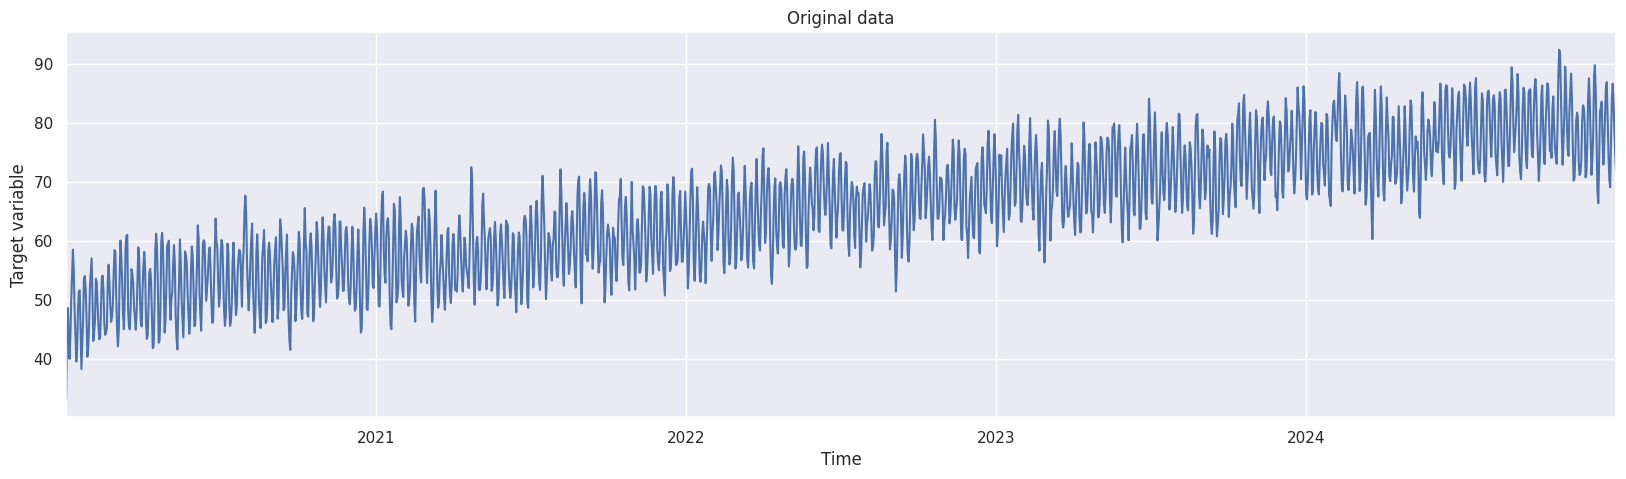

In [6]:
df.set_index("ds")["y"].plot(
    title="Original data", ylabel="Target variable", xlabel="Time"
)

<a name='fit-the-model'></a>
# Fit the model

In [7]:
start_date_filter = df["ds"] >= config["train_start_date"]
end_date_filter = df["ds"] <= config["train_end_date"]
df_train = df[start_date_filter & end_date_filter]
_LOG.info(hpandas.df_to_str(df_train, log_level=logging.INFO))

,ds,y,y.lag1
1,2020-01-02 00:00:00,33.141753,18.493428
2,2020-01-03 00:00:00,43.822941,33.141753
3,2020-01-04 00:00:00,48.654115,43.822941
,...,...,...
1458,2023-12-29 00:00:00,86.189145,81.430431
1459,2023-12-30 00:00:00,83.89076,86.189145
1460,2023-12-31 00:00:00,76.324779,83.89076


INFO  None


In Prophet, holidays can be customized to account for their effects on time series data.
Each holiday is defined as a specific date or set of recurring dates.
Additionally, you can extend the influence of a holiday to a range of days using
the `lower_window` and `upper_window` parameters:

 - `lower_window`: Specifies how many days before the holiday the effect starts.
 - `upper_window`: Specifies how many days after the holiday the effect ends.

For example:
 - To include Christmas Eve as part of the Christmas holiday effect, set
   `lower_window=-1` and `upper_window=0`.
 - To include Black Friday in addition to Thanksgiving, set
   `lower_window=0` and `upper_window=1`.

Additionally, you can customize the strength of the holiday effect for each holiday
using the `prior_scale` parameter. This allows finer control over the regularization
of each holiday's effect, balancing flexibility and overfitting.



In [8]:
# Construct a Dataframe with holidays.
holidays_df = pd.DataFrame(
    {
        "holiday": [
            "Christmas 2020",
            "Christmas 2021",
            "Christmas 2022",
            "Christmas 2023",
            "Christmas 2024",
        ],
        "ds": pd.to_datetime(config["data"]["holidays_dates"]),
        "lower_window": 0,
        "upper_window": 0,
    }
)
_LOG.info(hpandas.df_to_str(holidays_df, log_level=logging.INFO))

,holiday,ds,lower_window,upper_window
0,Christmas 2020,2020-12-25,0,0
1,Christmas 2021,2021-12-25,0,0
2,Christmas 2022,2022-12-25,0,0
3,Christmas 2023,2023-12-25,0,0
4,Christmas 2024,2024-12-25,0,0


INFO  None


In [9]:
forecaster = ProphetForecastModel(config["model"], holidays_df)
forecaster.fit(df_train)
model = forecaster.get_model()

INFO  Adding regressor: y.lag1


20:15:37 - cmdstanpy - INFO - CmdStan start processing


INFO  CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

20:15:42 - cmdstanpy - INFO - CmdStan done processing.



INFO  CmdStan done processing.


20:15:42 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_gl

WARNING Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scale vector is 0

Dimensionality:
- k (Mx1 array): M posterior samples of the initial slope
- m (Mx1 array): The initial intercept
- delta (MxN array): The slope change at each of N changepoints
- beta (MxK matrix): Coefficients for K seasonality features
- sigma_obs (Mx1 array): Noise level
- M=1 (meaning that only the point estimate is available) if MAP estimation, i.e. `mcmc_samples=0`

The number M (posterior samples) depends on:
- `mcmc_samples` provided by the user
- number of chains and the model internal mechanics that the user does not control
   - E.g., Prophet might be discarding some samples (e.g., through thinning) to reduce autocorrelation between the samples or to improve convergence

Scaling:
- Prophet perofrorms scaling internally, i.e. time is mapped to be on [0, 1] and Y is scaled by model.y_scale
- Where `y_scale` is controlled by the user and can be `absmax` or `minmax` scaling
- TODO(Grisha): consider rescaling coefficients in order to compare them to the ground truth

In [10]:
_LOG.info("Model Scale: %s, Model Min: %s", model.y_scale, model.y_min)

INFO  Model Scale: 53.04739142107461, Model Min: 33.141753128860344


INFO  Shape of the intercept = (600,)
INFO  Intercept point estimate = 0.4776499183333334


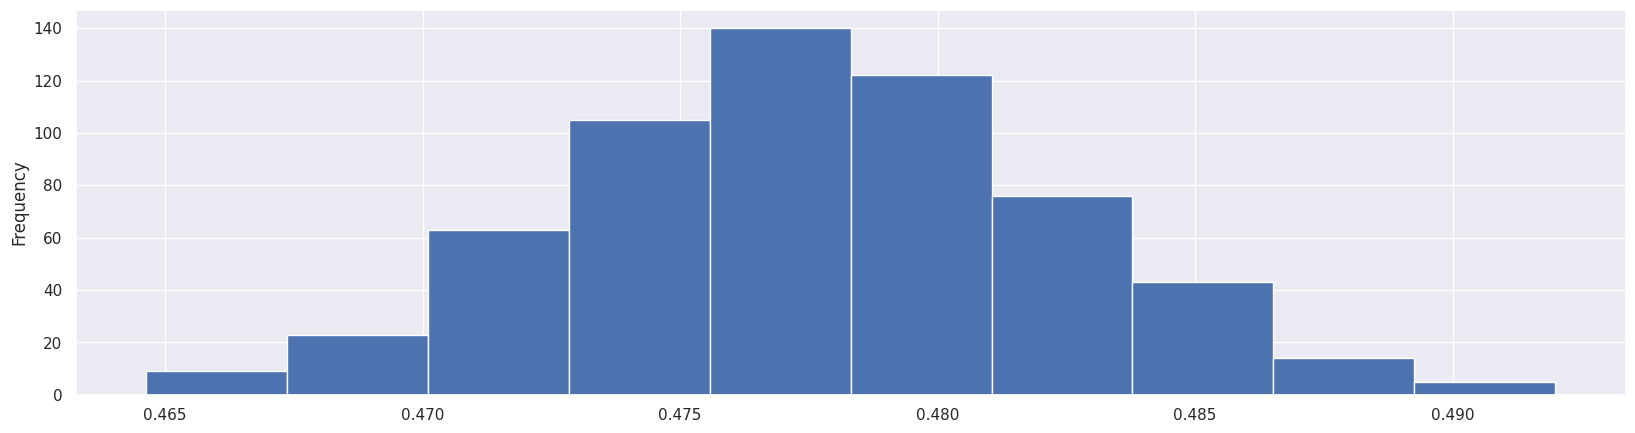

In [11]:
estimated_intercept = model.params["m"]
pd.Series(estimated_intercept).plot(kind="hist")
_LOG.info("Shape of the intercept = %s", estimated_intercept.shape)
_LOG.info("Intercept point estimate = %s", estimated_intercept.mean())

INFO  Shape of the slope = (600,)
INFO  Slope point estimate = 0.14805914783433333


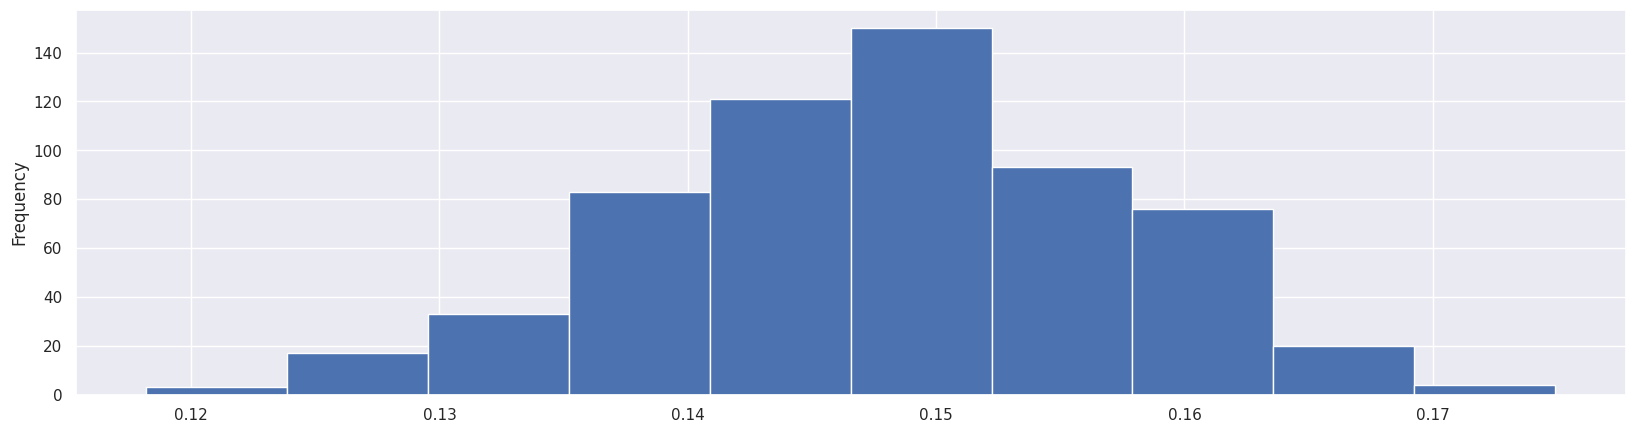

In [12]:
estimated_slope = model.params["k"]
pd.Series(estimated_slope).plot(kind="hist")
_LOG.info("Shape of the slope = %s", estimated_slope.shape)
_LOG.info("Slope point estimate = %s", estimated_slope.mean())

Estimated value of the autoregression coefficient is close to the ground truth.

In [13]:
# Use `regressor_coefficients()` to extract external regressors' coefficient. Unlike the other coeficients these
# already takes into account the internal scaling, thus can be directly compared to the original coefficients.
regressor_coefficients = prhu.regressor_coefficients(model)
_LOG.info(hpandas.df_to_str(regressor_coefficients, log_level=logging.INFO))
_LOG.info(
    "True value of the autoregression coefficient = %s", config["data"]["phi"]
)

,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,y.lag1,additive,62.375947,0.657769,0.690586,0.726726


INFO  None
INFO  True value of the autoregression coefficient = 0.7


Description:
- `weekly_delim_1` is the coefficient for the sine term
- `weekly_delim_2` is the coefficient for the cosine term
- in general the number of the Fourier coefficients is 2xN (i.e. 1 for the sine and 1 for the cosine), where N is Fourier order (i.e. 1 in our case)
- then we have 5 coefficients for 5 holidays
- and finally coefficients for the lagged feature
- each coefficient is a vector of length M (number of posterior samples)

Once the params are extracted:
- one can easily obtain a point estimate by averaging the values within a column
- compute confidence intervals using `np.quatile()`
- study the entire parameter's distribution

In [14]:
# Use this table to identify coefficients' indices in the regressors' matrix.
col_names = model.make_all_seasonality_features(df_train)[0].columns
coefficients_df = pd.DataFrame(model.params["beta"], columns=col_names)
_LOG.info(hpandas.df_to_str(coefficients_df, log_level=logging.INFO))

,weekly_delim_1,weekly_delim_2,Christmas 2020_delim_+0,Christmas 2021_delim_+0,Christmas 2022_delim_+0,Christmas 2023_delim_+0,Christmas 2024_delim_+0,y.lag1
0,0.014525,0.106445,-0.004303,0.034555,0.037817,0.045965,-0.034779,0.130349
1,0.014305,0.106149,0.003194,0.116102,-0.004076,0.023408,-0.005262,0.130403
2,0.018312,0.102488,-0.016917,0.026278,0.029522,0.068892,0.051722,0.125563
,...,...,...,...,...,...,...,...
597,0.020514,0.104195,-0.009407,0.045334,0.070011,0.037772,0.130838,0.122673
598,0.024316,0.104279,0.032108,0.053295,0.058667,0.032558,0.067022,0.116306
599,0.021397,0.104372,-0.018506,0.02209,0.028544,0.050648,-0.127032,0.123689


INFO  None


<a name='predict'></a>
# Predict

In [15]:
start_date_filter = df["ds"] >= config["test_start_date"]
end_date_filter = df["ds"] <= config["test_end_date"]
df_test = df[start_date_filter & end_date_filter].reset_index(drop=True)
_LOG.info(hpandas.df_to_str(df_test, log_level=logging.INFO))

,ds,y,y.lag1
0,2024-01-01 00:00:00,67.852807,76.324779
1,2024-01-02 00:00:00,67.038486,67.852807
2,2024-01-03 00:00:00,70.040899,67.038486
,...,...,...
363,2024-12-29 00:00:00,78.387492,83.360033
364,2024-12-30 00:00:00,74.449184,78.387492
365,2024-12-31 00:00:00,71.713198,74.449184


INFO  None


In [16]:
# Predict on the entire data and then analyze the tran and test split seperately to gain more insights.
forecast = forecaster.predict(df)
forecast = forecast.merge(df, how="inner", on=["ds"])
forecast["residual"] = forecast["y"] - forecast["yhat"]
_LOG.info(hpandas.df_to_str(forecast, log_level=logging.INFO))

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas 2020,Christmas 2020_lower,Christmas 2020_upper,Christmas 2021,Christmas 2021_lower,Christmas 2021_upper,Christmas 2022,Christmas 2022_lower,Christmas 2022_upper,Christmas 2023,Christmas 2023_lower,Christmas 2023_upper,Christmas 2024,Christmas 2024_lower,Christmas 2024_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,extra_regressors_additive_lower,extra_regressors_additive_upper,holidays,holidays_lower,holidays_upper,weekly,weekly_lower,weekly_upper,y.lag1_x,y.lag1_lower,y.lag1_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,y,y.lag1_y,residual
0,2020-01-02 00:00:00,58.479835,29.630496,37.49295,58.017331,59.011514,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-24.820094,-26.330126,-23.436641,-30.304675,-31.890579,-28.86457,0.0,0.0,0.0,5.484581,5.325513,5.63432,-30.304675,-31.890579,-28.86457,0.0,0.0,0.0,33.659742,33.141753,18.493428,-0.517989
1,2020-01-03 00:00:00,58.485219,38.493141,46.714654,58.023218,59.016251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-15.87334,-17.029703,-14.815644,-20.188739,-21.245256,-19.229353,0.0,0.0,0.0,4.315399,4.118439,4.522119,-20.188739,-21.245256,-19.229353,0.0,0.0,0.0,42.611878,43.822941,33.141753,1.211063
2,2020-01-04 00:00:00,58.490602,41.589322,49.472083,58.029105,59.020988,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-12.915821,-13.844535,-12.099836,-12.812455,-13.482956,-12.203596,0.0,0.0,0.0,-0.103367,-0.375319,0.165333,-12.812455,-13.482956,-12.203596,0.0,0.0,0.0,45.57478,48.654115,43.822941,3.079335
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1823,2024-12-29 00:00:00,68.293487,74.685082,82.064595,67.511843,69.009089,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.047032,9.496676,10.638765,14.491327,13.802686,15.249687,0.0,0.0,0.0,-4.444295,-4.652716,-4.238843,14.491327,13.802686,15.249687,0.0,0.0,0.0,78.340519,78.387492,83.360033,0.046973
1824,2024-12-30 00:00:00,68.298871,70.324653,78.006601,67.51657,69.015107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.618778,5.052669,6.233206,11.057357,10.531902,11.63601,0.0,0.0,0.0,-5.438579,-5.585564,-5.281503,11.057357,10.531902,11.63601,0.0,0.0,0.0,73.917649,74.449184,78.387492,0.531535
1825,2024-12-31 00:00:00,68.304254,70.423646,78.116419,67.521297,69.021124,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.000113,5.40829,6.660579,8.337614,7.941404,8.773938,0.0,0.0,0.0,-2.337502,-2.591154,-2.07954,8.337614,7.941404,8.773938,0.0,0.0,0.0,74.304366,71.713198,74.449184,-2.591169


INFO  None


<a name='analyze-the-results'></a>
# Analyze the results

In [17]:
ins_forecast = forecast[forecast["ds"] <= config["train_end_date"]]
ins_forecast.tail(5)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas 2020,Christmas 2020_lower,Christmas 2020_upper,Christmas 2021,Christmas 2021_lower,Christmas 2021_upper,Christmas 2022,Christmas 2022_lower,Christmas 2022_upper,Christmas 2023,Christmas 2023_lower,Christmas 2023_upper,Christmas 2024,Christmas 2024_lower,Christmas 2024_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,extra_regressors_additive_lower,extra_regressors_additive_upper,holidays,holidays_lower,holidays_upper,weekly,weekly_lower,weekly_upper,y.lag1_x,y.lag1_lower,y.lag1_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,y,y.lag1_y,residual
1455,2023-12-27,66.312454,70.868751,78.207668,65.796272,66.790386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.091214,7.598475,8.625148,5.567452,5.302882,5.858808,0.0,0.0,0.0,2.523762,2.265541,2.779565,5.567452,5.302882,5.858808,0.0,0.0,0.0,74.403668,75.593189,70.437866,1.189521
1456,2023-12-28,66.317837,77.237777,84.806330,65.800935,66.796364,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.612230,14.093081,15.158633,9.127649,8.693895,9.605317,0.0,0.0,0.0,5.484581,5.325513,5.634320,9.127649,8.693895,9.605317,0.0,0.0,0.0,80.930067,81.430431,75.593189,0.500364
1457,2023-12-29,66.323220,79.727248,87.698964,65.805598,66.802341,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.474168,16.961120,18.044610,13.158769,12.533453,13.847394,0.0,0.0,0.0,4.315399,4.118439,4.522119,13.158769,12.533453,13.847394,0.0,0.0,0.0,83.797389,86.189145,81.430431,2.391756
1458,2023-12-30,66.328604,79.085651,86.666028,65.810261,66.808319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.341706,15.775149,16.964309,16.445073,15.663589,17.305676,0.0,0.0,0.0,-0.103367,-0.375319,0.165333,16.445073,15.663589,17.305676,0.0,0.0,0.0,82.670310,83.890760,86.189145,1.220451
1459,2023-12-31,66.333987,72.706136,80.524672,65.814925,66.814296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.413545,9.846055,11.023231,14.857840,14.151782,15.635380,0.0,0.0,0.0,-4.444295,-4.652716,-4.238843,14.857840,14.151782,15.635380,0.0,0.0,0.0,76.747532,76.324779,83.890760,-0.422752


<Axes: >

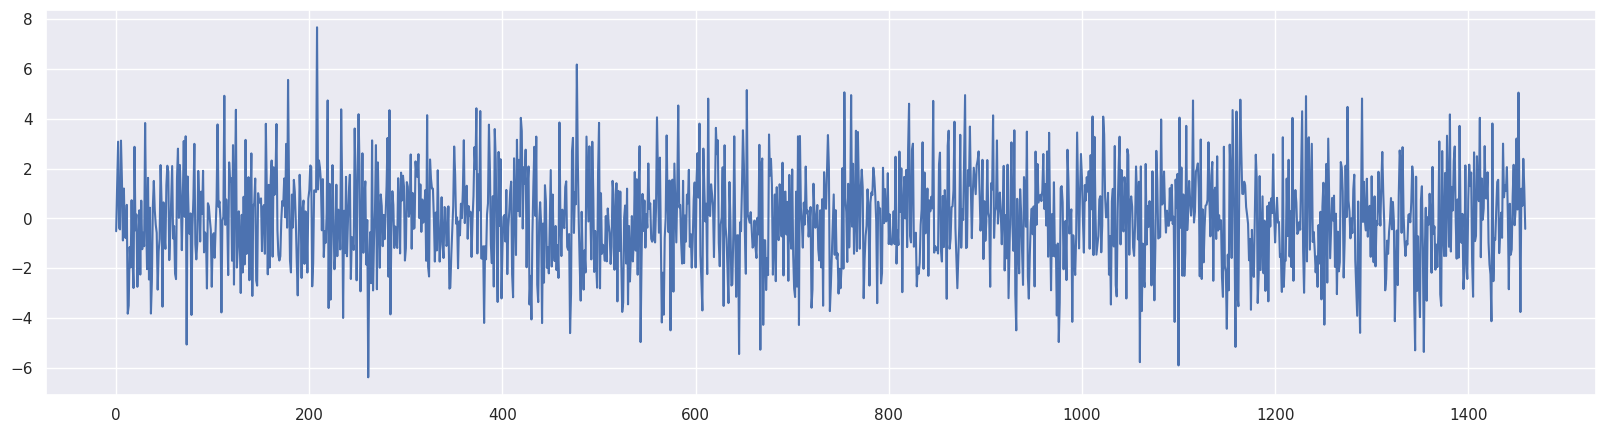

In [18]:
ins_forecast["residual"].plot()

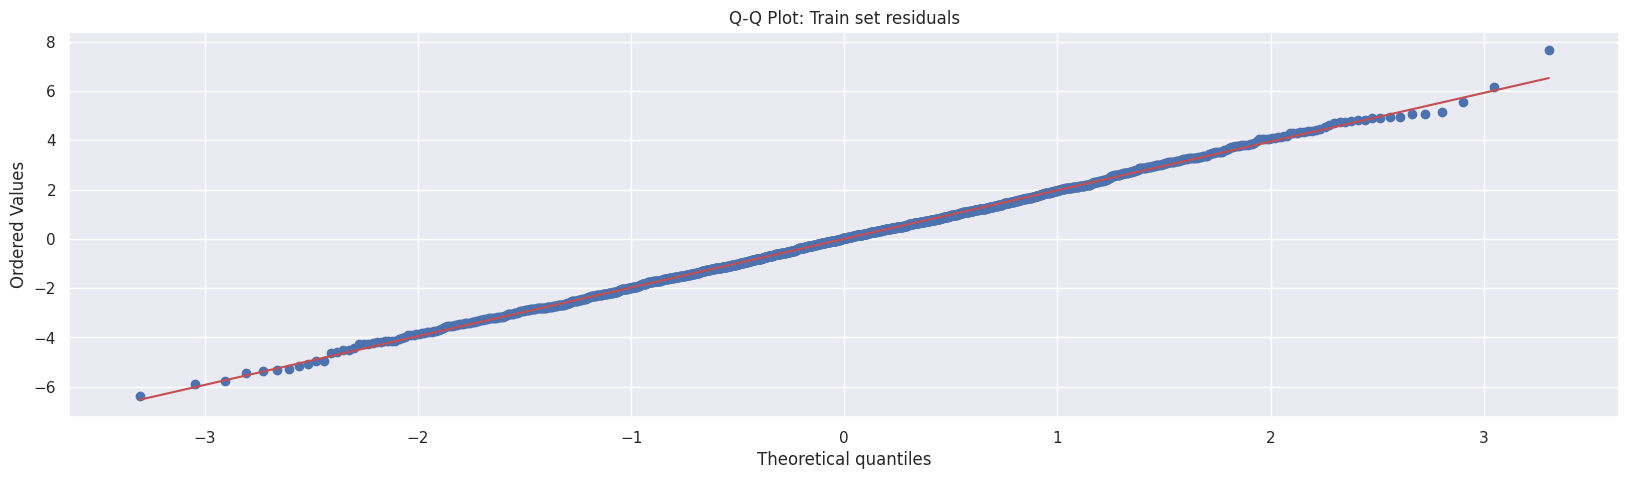

In [19]:
stats.probplot(ins_forecast["residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot: Train set residuals")
plt.show()

Residuals are normal distributed, hence the modle is working fine.

Text(0.5, 1.0, 'Observed vs predicted data, train set')

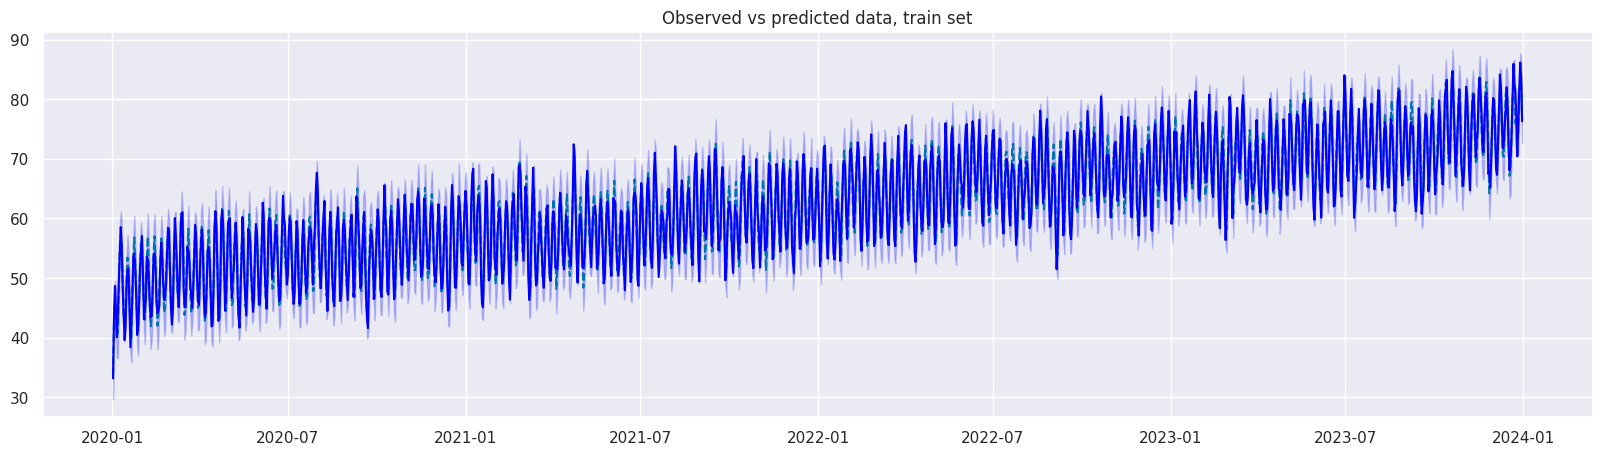

In [20]:
plt.plot(
    ins_forecast["ds"],
    ins_forecast["yhat"],
    label="Point Estimate",
    ls="--",
    c="#0072B2",
)
plt.plot(
    ins_forecast["ds"], ins_forecast["y"], label="Observed data", color="blue"
)

# Plot confidence/prediction intervals
plt.fill_between(
    ins_forecast["ds"],
    ins_forecast["yhat_lower"],
    ins_forecast["yhat_upper"],
    color="blue",
    alpha=0.2,
    label="Confidence Interval",
)
plt.title("Observed vs predicted data, train set")

<a name='`prophet.plot()`'></a>
### `Prophet.plot()`

The `Prophet.plot()` function is used to visualize the forecast generated by the Prophet model. It provides a comprehensive view of the predicted trend and uncertainty intervals over the forecast horizon.

**Key Features:**
1. **Forecast Line**: Displays the predicted values (`yhat`), representing the central forecast.
2. **Uncertainty Intervals**:
   - Shaded regions represent the uncertainty intervals (`yhat_lower` and `yhat_upper`), capturing the range within which the forecast is expected to fall.
   - By default, this represents a 95% confidence interval.
3. **Historical Data**:
   - Overlaid as points to show how the forecast aligns with the actual data.

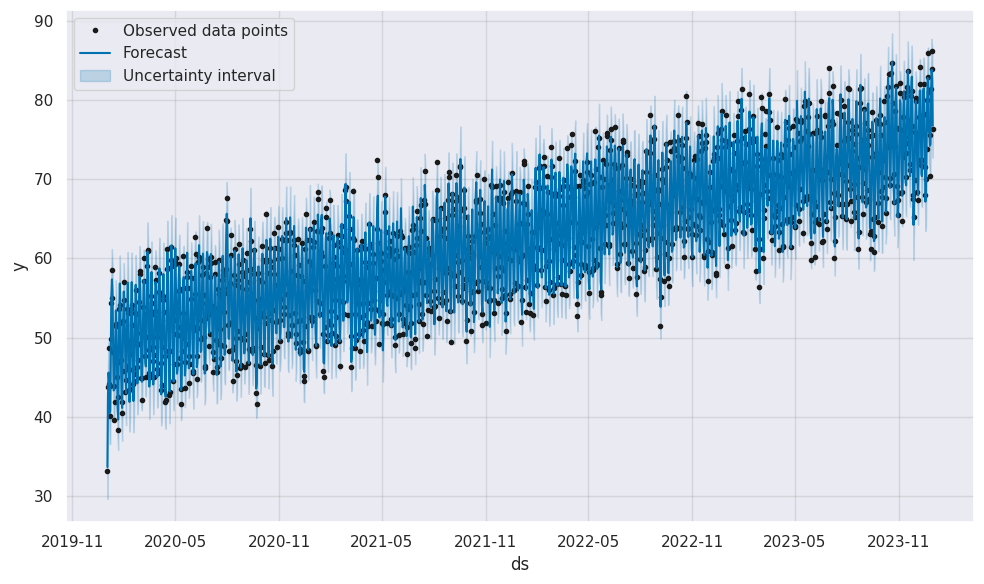

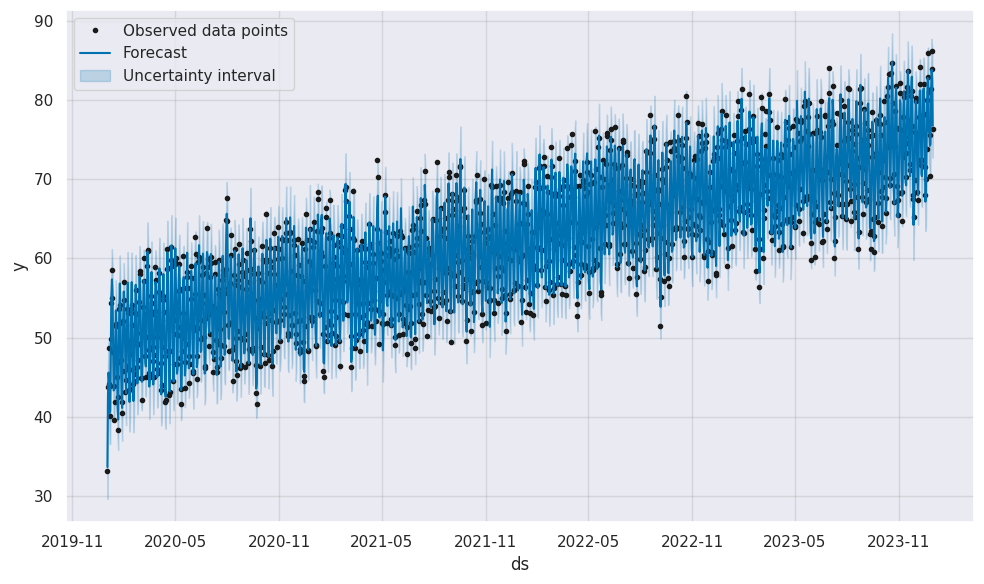

In [21]:
model.plot(ins_forecast, include_legend=True)

<a name='`prophet.plot_components()`'></a>
### `Prophet.plot_components()`

The `Prophet.plot_components()` function provides a breakdown of the individual components contributing to the forecast. This helps understand **why** the forecast behaves as it does.

**Components Visualized:**
1. **Trend**:
   - Displays the underlying trend in the data, excluding seasonality and holidays.
   - Useful for identifying long-term growth or decline patterns.
2. **Seasonality**:
   - Shows recurring patterns (e.g., daily, weekly, yearly seasonality) identified from the data.
   - If multiple seasonalities are specified, they are plotted separately.
3. **Holidays (if applicable)**:
   - Visualizes the effect of specified holidays on the forecast.
   - Helps identify spikes or dips caused by holidays.

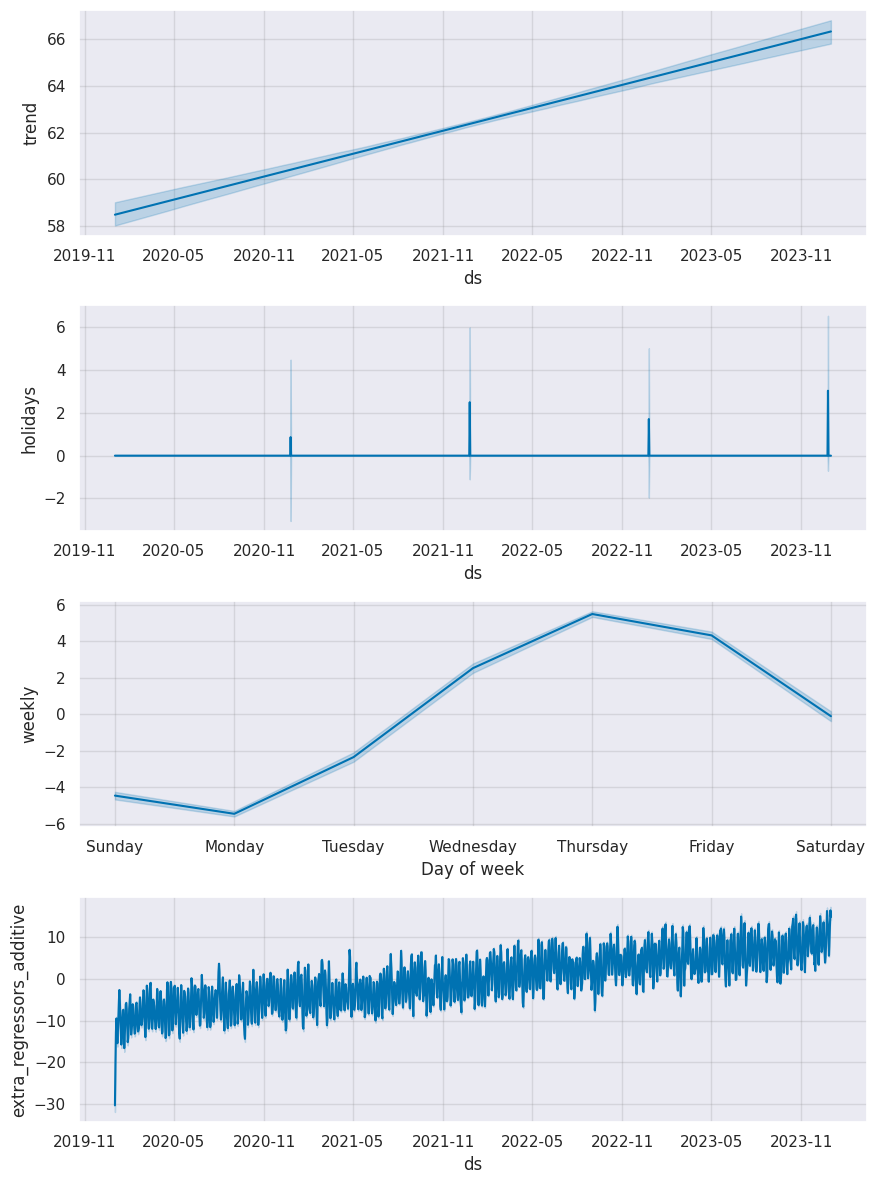

In [22]:
fig2 = model.plot_components(ins_forecast)

In [23]:
oos_forecast = forecast[forecast["ds"] >= config["test_start_date"]]
oos_forecast.tail(5)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas 2020,Christmas 2020_lower,Christmas 2020_upper,Christmas 2021,Christmas 2021_lower,Christmas 2021_upper,Christmas 2022,Christmas 2022_lower,Christmas 2022_upper,Christmas 2023,Christmas 2023_lower,Christmas 2023_upper,Christmas 2024,Christmas 2024_lower,Christmas 2024_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,extra_regressors_additive_lower,extra_regressors_additive_upper,holidays,holidays_lower,holidays_upper,weekly,weekly_lower,weekly_upper,y.lag1_x,y.lag1_lower,y.lag1_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,y,y.lag1_y,residual
1821,2024-12-27,68.282721,83.434490,90.934890,67.502390,68.997053,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.083789,18.487665,19.748647,14.768390,14.066583,15.541249,0.0,0.0,0.0,4.315399,4.118439,4.522119,14.768390,14.066583,15.541249,0.0,0.0,0.0,87.366510,86.611489,83.761234,-0.755021
1822,2024-12-28,68.288104,80.816223,88.986753,67.507117,69.003071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.633371,16.049948,17.270387,16.736738,15.941394,17.612605,0.0,0.0,0.0,-0.103367,-0.375319,0.165333,16.736738,15.941394,17.612605,0.0,0.0,0.0,84.921475,83.360033,86.611489,-1.561442
1823,2024-12-29,68.293487,74.685082,82.064595,67.511843,69.009089,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.047032,9.496676,10.638765,14.491327,13.802686,15.249687,0.0,0.0,0.0,-4.444295,-4.652716,-4.238843,14.491327,13.802686,15.249687,0.0,0.0,0.0,78.340519,78.387492,83.360033,0.046973
1824,2024-12-30,68.298871,70.324653,78.006601,67.516570,69.015107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.618778,5.052669,6.233206,11.057357,10.531902,11.636010,0.0,0.0,0.0,-5.438579,-5.585564,-5.281503,11.057357,10.531902,11.636010,0.0,0.0,0.0,73.917649,74.449184,78.387492,0.531535
1825,2024-12-31,68.304254,70.423646,78.116419,67.521297,69.021124,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.000113,5.408290,6.660579,8.337614,7.941404,8.773938,0.0,0.0,0.0,-2.337502,-2.591154,-2.079540,8.337614,7.941404,8.773938,0.0,0.0,0.0,74.304366,71.713198,74.449184,-2.591169


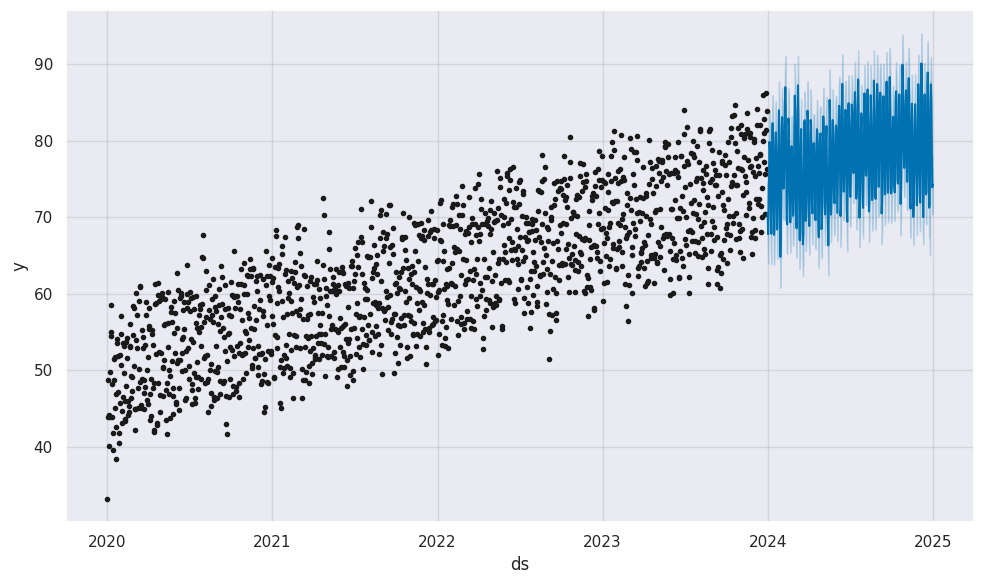

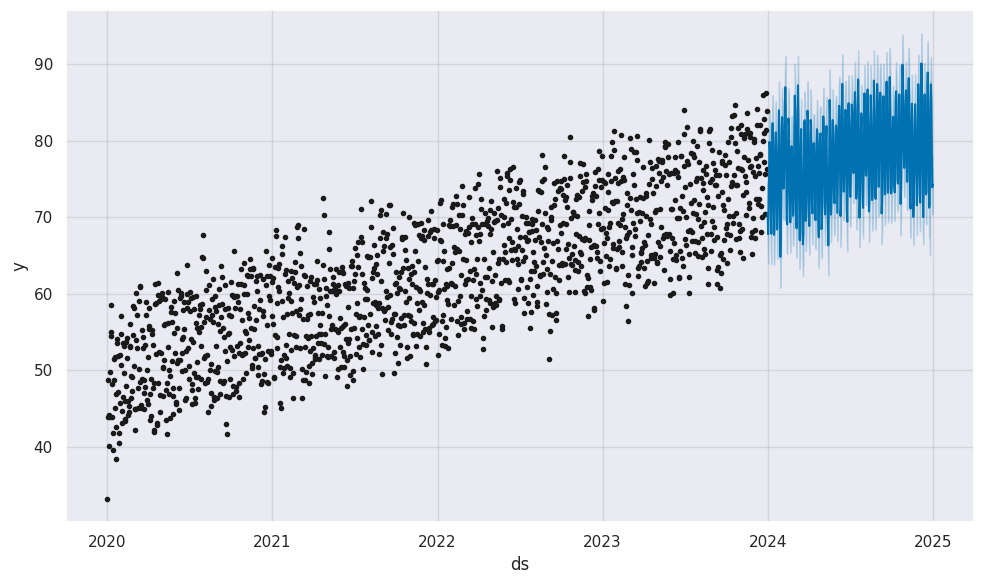

In [24]:
model.plot(oos_forecast)

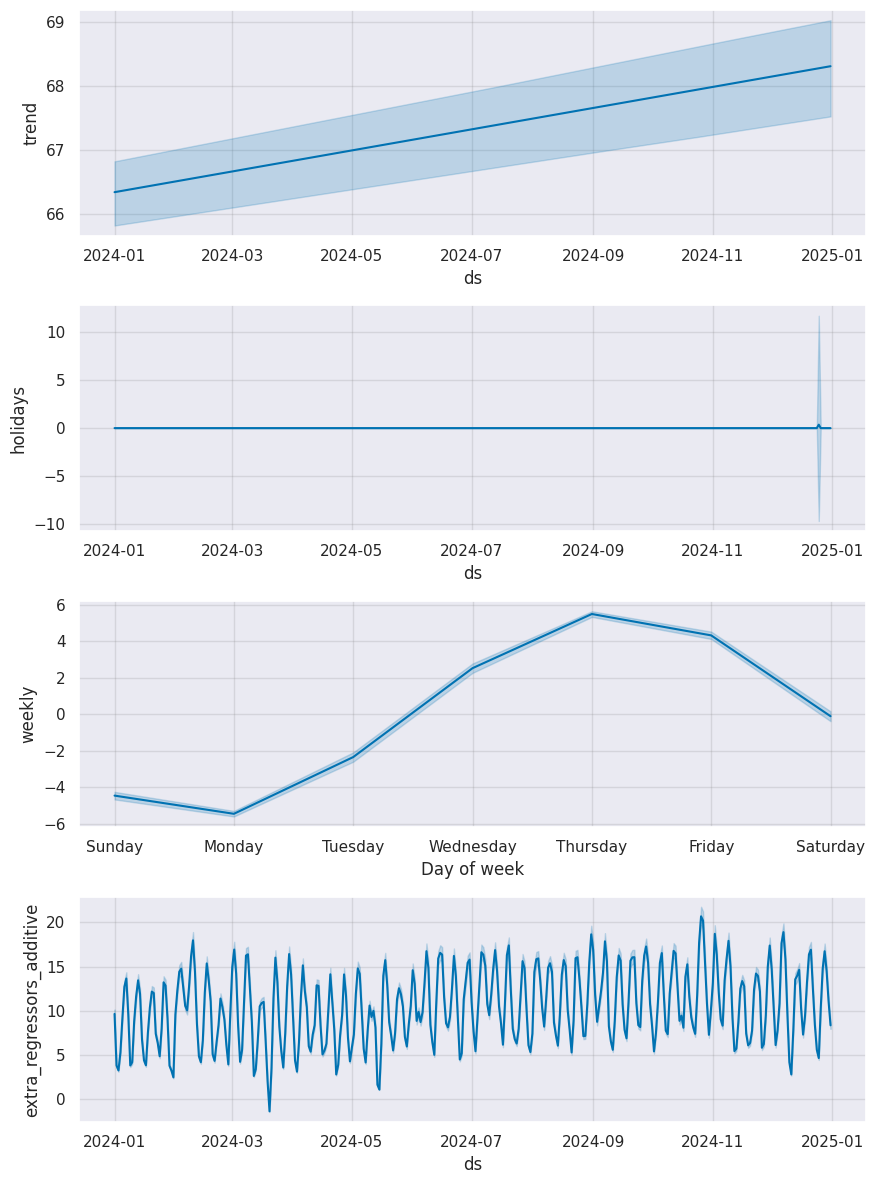

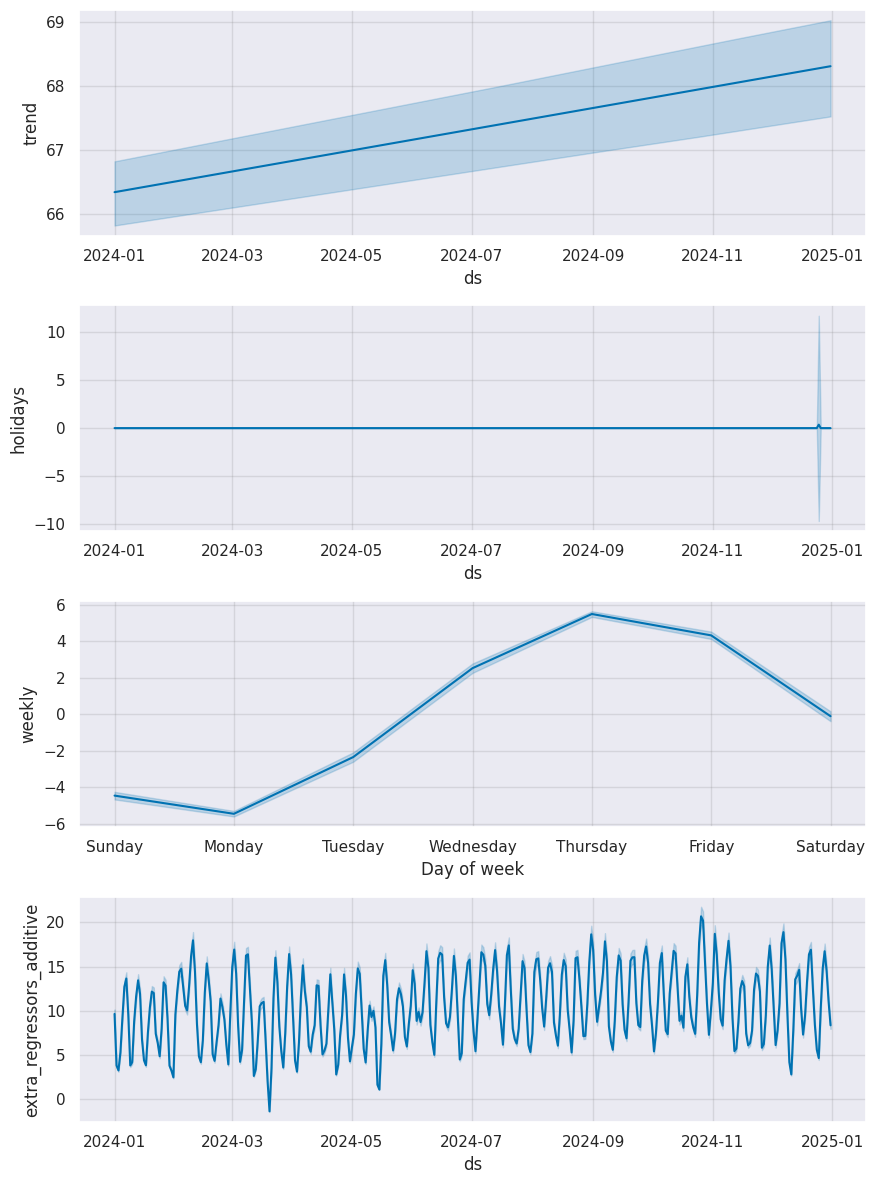

In [25]:
model.plot_components(oos_forecast)

<a name='prophet.plot_plotly()'></a>
### Prophet.plot_plotly()
The Prophet.plot_plotly() function provides an interactive visualization of the forecast using the Plotly library. This is an alternative to Prophet.plot(), which uses Matplotlib for static plots.

With plot_plotly(), you can dynamically explore the forecast, zoom in/out, hover over data points to see values, and pan through the graph, making it especially useful for presentations or exploring large datasets.

In [26]:
# Create Prophet's interactive plot
fig = plo.plot_plotly(model, forecast)

# Add ground truth (actual values)
fig.add_trace(
    go.Scatter(
        x=df_test["ds"],
        y=df_test["y"],
        mode="markers",
        name="Ground Truth",
        marker=dict(color="red", size=5),
    )
)

# Update layout
fig.update_layout(
    title="Forecast vs Ground Truth",
    xaxis_title="Date",
    yaxis_title="Values",
    legend=dict(orientation="h", y=-0.2),
)

# Show the plot
fig.show()

<a name='performance-metrics'></a>
# Performance metrics

Prophet provides performance metric calculation only on the cross validation data. To test the performance of prophet model on test split we will be using sklearn metrics.

In [27]:
# Calculate metrics
mae = metrics.mean_absolute_error(oos_forecast["y"], oos_forecast["yhat"])
rmse = metrics.mean_squared_error(oos_forecast["y"], oos_forecast["yhat"])
mape = (
    abs(oos_forecast["y"] - oos_forecast["yhat"]) / oos_forecast["y"]
).mean() * 100

_LOG.info("MAE=%s, RMSE=%s, MAPE=%s", mae, rmse, mape)

INFO  MAE=1.6063193480382973, RMSE=4.050528624903883, MAPE=2.0930031318358013


<a name='cross-validation'></a>
# Cross Validation

`cross_validation` method does not take in the dataset as input so the cross validation is done on the data used in `model.fit()`

- Sliding Window Approach:

The historical dataset is split into multiple training and testing sets using a sliding window approach.
Each training set ends at a specific cutoff date, and the model is tested on the subsequent data.

- Parameters:

    - initial: The size of the initial training period (e.g., 3 years).
    - horizon: The forecast horizon for which predictions are made (e.g., 30 days).
    - period: The spacing between cutoff dates (e.g., 90 days).
This setup generates overlapping training and testing periods, simulating how the model performs when trained on different subsets of the data.

Prophet's cross_validation function adheres to the rolling approach. Each fold contains:

- A training set determined by the initial parameter (e.g., the first 3 years of data).
- A validation set that starts right after the training set and spans the horizon period (e.g., 90 days into the future).
- The window is shifted forward by the period parameter (e.g., every 180 days), creating new training and validation splits.

In [28]:
df_cv = diagnostics.cross_validation(
    model=model,
    # Use 2 years as initial training period.
    initial="730 days",
    # Move rolling window every 180 days.
    period="180 days",
    horizon="365 days",
)

INFO  Making 3 forecasts with cutoffs between 2022-01-05 00:00:00 and 2022-12-31 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

20:15:45 - cmdstanpy - INFO - CmdStan start processing


INFO  CmdStan start processing


chain 1 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

20:15:56 - cmdstanpy - INFO - CmdStan done processing.



INFO  CmdStan done processing.


20:15:56 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scal

WARNING Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scale vector is 0, but must b

In [29]:
df_perf = diagnostics.performance_metrics(df_cv)
_LOG.info(hpandas.df_to_str(df_perf, log_level=logging.INFO))

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days 00:00:00,4.657678,2.158165,1.716065,0.02621,0.022756,0.026215,0.926606
1,38 days 00:00:00,4.621156,2.149687,1.720446,0.026195,0.022756,0.026223,0.932722
2,39 days 00:00:00,4.480881,2.116809,1.687864,0.025702,0.022732,0.02573,0.93578
,...,...,...,...,...,...,...,...
326,363 days 00:00:00,3.884978,1.971035,1.563482,0.022255,0.018844,0.022188,0.944954
327,364 days 00:00:00,3.755188,1.937831,1.527727,0.021672,0.017203,0.02162,0.944954
328,365 days 00:00:00,3.677647,1.917719,1.499841,0.021214,0.016138,0.02118,0.944954


INFO  None


In [30]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2022-01-06,66.379890,62.654777,70.253286,66.970390,2022-01-05
1,2022-01-07,69.699555,65.688674,73.536345,71.847992,2022-01-05
2,2022-01-08,68.636020,64.718970,72.724461,72.231540,2022-01-05
3,2022-01-09,64.545968,60.830721,68.731737,66.863977,2022-01-05
4,2022-01-10,59.868415,56.153616,63.745436,56.392094,2022-01-05


/home/alvinoangelo/src/venv/client_venv.helpers/lib/python3.12/site-packages/prophet/plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

/home/alvinoangelo/src/venv/client_venv.helpers/lib/python3.12/site-packages/prophet/plot.py:548: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



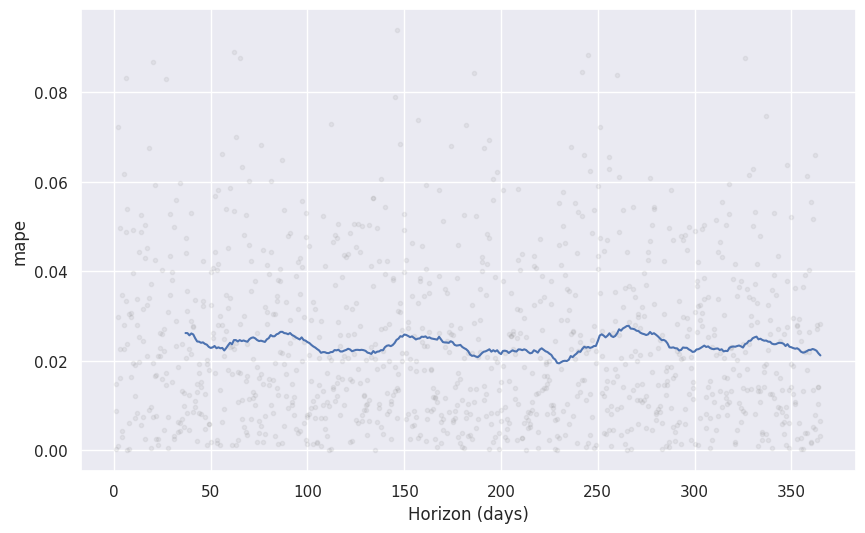

In [31]:
# Plot Mean Absolute Percentage Error (MAPE)
fig = plo.plot_cross_validation_metric(df_cv, metric="mape")